In [2]:
import pandas as pd
import sklearn
import torch
from datasets import load_dataset

print("✅ pandas:", pd.__version__)
print("✅ scikit-learn:", sklearn.__version__)
print("✅ torch:", torch.__version__)
print("✅ datasets: ready")
print("\n🚀 Environment is fully ready!")

✅ pandas: 3.0.3
✅ scikit-learn: 1.9.0
✅ torch: 2.12.1+cpu
✅ datasets: ready

🚀 Environment is fully ready!


In [3]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("heegyu/news-category-dataset")
df = pd.DataFrame(dataset["train"])

print(df.shape)
print(df.columns)
print(df["category"].value_counts())

(209527, 6)
Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='str')
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          137

In [4]:
mapping = {
    "POLITICS": "Politics",
    "IMPACT": "Politics",
    "BLACK VOICES": "Politics",
    "QUEER VOICES": "Politics",
    "LATINO VOICES": "Politics",
    "WOMEN": "Politics",

    "BUSINESS": "Business",
    "MONEY": "Business",
    "TECH": "Business",
    "MEDIA": "Business",
    "GREEN": "Business",

    "SPORTS": "Sports",

    "ENTERTAINMENT": "Entertainment",
    "COMEDY": "Entertainment",
    "ARTS": "Entertainment",
    "CULTURE & ARTS": "Entertainment",
    "STYLE & BEAUTY": "Entertainment",
    "STYLE": "Entertainment",

    "WELLNESS": "Lifestyle",
    "TRAVEL": "Lifestyle",
    "FOOD & DRINK": "Lifestyle",
    "HOME & LIVING": "Lifestyle",
    "PARENTING": "Lifestyle",
    "PARENTS": "Lifestyle",
    "WEDDINGS": "Lifestyle",
    "DIVORCE": "Lifestyle",

    "WORLD NEWS": "World",
    "THE WORLDPOST": "World",
    "WORLDPOST": "World",
    "RELIGION": "World",

    "CRIME": "Crime",

    "EDUCATION": "Education",
    "COLLEGE": "Education",
}

df["final_category"] = df["category"].map(mapping)

print(df["final_category"].value_counts(dropna=False))
print(df["final_category"].isna().sum())

final_category
Lifestyle        58330
Politics         54718
Entertainment    37413
NaN              20732
Business         15418
World            12119
Sports            5077
Crime             3562
Education         2158
Name: count, dtype: int64
20732


In [5]:
df_clean = df.dropna(subset=["final_category"]).copy()

print(df_clean.shape)
print(df_clean["final_category"].value_counts())

(188795, 7)
final_category
Lifestyle        58330
Politics         54718
Entertainment    37413
Business         15418
World            12119
Sports            5077
Crime             3562
Education         2158
Name: count, dtype: int64


In [6]:
df_clean.to_csv("news_domain_tagging_cleaned.csv", index=False)

In [7]:
df_clean["text"] = df_clean["headline"].fillna("") + " " + df_clean["short_description"].fillna("")
df_clean["text"] = df_clean["text"].str.strip()

print(df_clean[["text", "final_category"]].head())

                                                text final_category
2  23 Of The Funniest Tweets About Cats And Dogs ...  Entertainment
3  The Funniest Tweets From Parents This Week (Se...      Lifestyle
7  Puerto Ricans Desperate For Water After Hurric...          World
8  How A New Documentary Captures The Complexity ...  Entertainment
9  Biden At UN To Call Russian War An Affront To ...          World


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

X = df_clean["text"]
y = df_clean["final_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

d:\INTERNSHIP PROJECT\ARTICLE DOMAIN TAGGING\article-domain-tagger\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.7569850896475012
F1 macro: 0.678540607746844
               precision    recall  f1-score   support

     Business       0.55      0.70      0.61      3083
        Crime       0.45      0.75      0.56       712
    Education       0.35      0.70      0.47       432
Entertainment       0.78      0.79      0.78      7483
    Lifestyle       0.85      0.83      0.84     11666
     Politics       0.86      0.66      0.75     10944
       Sports       0.63      0.83      0.72      1015
        World       0.63      0.77      0.69      2424

     accuracy                           0.76     37759
    macro avg       0.64      0.75      0.68     37759
 weighted avg       0.78      0.76      0.76     37759



In [9]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

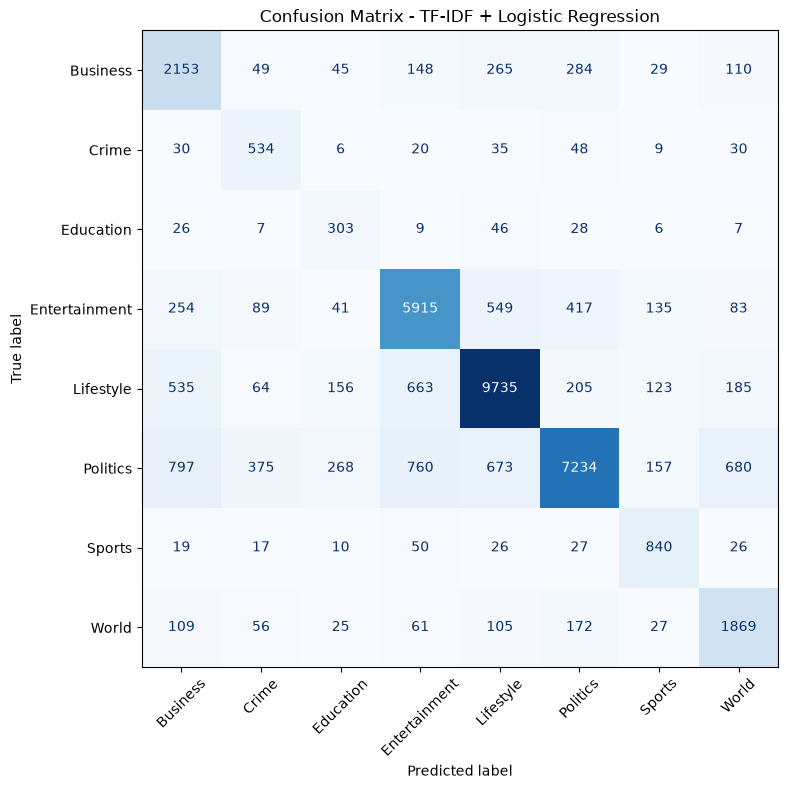

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print("F1 macro:", f1_score(y_test, svm_pred, average="macro"))
print(classification_report(y_test, svm_pred))

Accuracy: 0.7742260123414285
F1 macro: 0.6860826278608578
               precision    recall  f1-score   support

     Business       0.58      0.64      0.61      3083
        Crime       0.52      0.62      0.56       712
    Education       0.44      0.53      0.48       432
Entertainment       0.79      0.80      0.79      7483
    Lifestyle       0.84      0.86      0.85     11666
     Politics       0.82      0.73      0.78     10944
       Sports       0.68      0.77      0.72      1015
        World       0.66      0.73      0.69      2424

     accuracy                           0.77     37759
    macro avg       0.67      0.71      0.69     37759
 weighted avg       0.78      0.77      0.78     37759

